In [1]:
from qiskit import QuantumCircuit
from qiskit_aer.primitives import Sampler
import math

In [ ]:
def oracle_1111(qc):
    # Apply multi-controlled Z gate
    qc.h(3)
    qc.mcx([0, 1, 2], 3)
    qc.h(3)

def diffuser(qc):
    qc.h(range(4))
    qc.x(range(4))

    oracle_1111(qc)

    qc.x(range(4))
    qc.h(range(4))

n = 4
qc = QuantumCircuit(n, n)

# Step 1: Initialize uniform superposition
qc.h(range(n))

# Step 2: Grover iterations
iterations = 3
for _ in range(iterations):
    oracle_1111(qc)
    diffuser(qc)

# Step 3: Measure
qc.measure(range(n), range(n))
qc.draw()

sampler = Sampler()
result = sampler.run(qc,shots = 1024).result()
counts = result.quasi_dists[0]

print(counts)

import matplotlib.pyplot as plt

# Number of qubits
n = 4

# Sort states 0 → 15
states = sorted(counts.keys())

labels = [format(s, f'0{n}b') for s in states]
values = [counts[s] for s in states]

plt.figure(figsize=(8, 4))
plt.bar(labels, values)

plt.xlabel("Computational Basis States")
plt.ylabel("Probability")
plt.title("4-Qubit Grover Output Distribution (Target = |1111⟩)")

plt.ylim(0, 1)
plt.grid(axis='y', alpha=0.3)

plt.show()


In [16]:
noise_model = NoiseModel()

#single-qubit Errors (T1/T2)
# Amplitude damping (T1-like)
# amp_error = amplitude_damping_error(0.1)
# noise_model.add_all_qubit_quantum_error(
#     amp_error,
#     ['h', 'x']
# )

# Phase damping (T2-like)
# phase_error = phase_damping_error(0.1)
# noise_model.add_all_qubit_quantum_error(
#     phase_error,
#     ['h', 'x']
# )

# # 2 qubit Errors (CX/CXX)
# cx_error = depolarizing_error(0.1, 2)

# noise_model.add_all_qubit_quantum_error(
#     cx_error,
#     ['cx']
# )

# # Measurement Errors
readout_error = ReadoutError([
    [0.9, 0.1],  # P(meas 0 | 0), P(1 | 0)
    [0.1, 0.9]   # P(meas 0 | 1), P(1 | 1)
])

noise_model.add_all_qubit_readout_error(readout_error)


Raw counts:
|0000⟩ : 20
|0001⟩ : 23
|0010⟩ : 27
|0011⟩ : 86
|0100⟩ : 18
|0101⟩ : 78
|0110⟩ : 86
|0111⟩ : 663
|1000⟩ : 24
|1001⟩ : 76
|1010⟩ : 89
|1011⟩ : 589
|1100⟩ : 89
|1101⟩ : 581
|1110⟩ : 567
|1111⟩ : 5176

Probabilities:
|0000⟩ : 0.0024
|0001⟩ : 0.0028
|0010⟩ : 0.0033
|0011⟩ : 0.0105
|0100⟩ : 0.0022
|0101⟩ : 0.0095
|0110⟩ : 0.0105
|0111⟩ : 0.0809
|1000⟩ : 0.0029
|1001⟩ : 0.0093
|1010⟩ : 0.0109
|1011⟩ : 0.0719
|1100⟩ : 0.0109
|1101⟩ : 0.0709
|1110⟩ : 0.0692
|1111⟩ : 0.6318


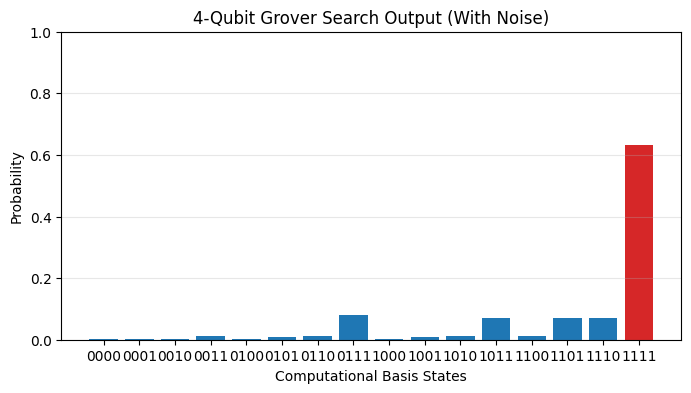

In [17]:
sim = AerSimulator(noise_model=noise_model)
tqc = transpile(qc, sim, optimization_level=0)
shots = 8192

result_noisy = sim.run(qc, shots=8192).result()
counts_noisy = result_noisy.get_counts()

print("Raw counts:")
for state, count in sorted(counts_noisy.items()):
    print(f"|{state}⟩ : {count}")

probs_noisy = {state: count / shots for state, count in counts_noisy.items()}

print("\nProbabilities:")
for state, prob in sorted(probs_noisy.items()):
    print(f"|{state}⟩ : {prob:.4f}")


import matplotlib.pyplot as plt

# Ensure all 3-qubit basis states are present
states = [format(i, '04b') for i in range(16)]
values = [probs_noisy.get(state, 0.0) for state in states]

# Highlight the marked state |1111⟩
colors = ['tab:red' if state == '1111' else 'tab:blue' for state in states]

plt.figure(figsize=(8, 4))
plt.bar(states, values, color=colors)

plt.xlabel("Computational Basis States")
plt.ylabel("Probability")
plt.title("4-Qubit Grover Search Output (With Noise)")
plt.ylim(0, 1)
plt.grid(axis='y', alpha=0.3)

plt.show()


